##### ***堆***
###### 堆(Heap)是计算机科学中一类特殊的数据结构的统称。堆通常是一个可以被看做一棵完全二叉树的数组对象。<br>**堆满足下列性质**：<br>1. 堆中某个节点的值总是不大于或不小于其父节点的值。<br>2. 堆总是一棵完全二叉树。<br>堆是利用完全二叉树的结构来维护一组数据，然后进行相关操作，一般的操作进行一次的时间复杂度在 O(1)~O(logn) 之间，堆通常用于动态分配和释放程序所使用的对象。若为优先队列的使用场景，普通数组或者顺序数组，最差情况为 O(n^2)，堆这种数据结构也可以提高入队和出队的效率。
###### 二叉堆是一颗完全二叉树，且堆中某个节点的值总是不大于其父节点的值，该完全二叉树的深度为 k，除第 k 层外，其它各层 (1～k-1) 的结点数都达到最大个数，第k 层所有的结点都连续集中在最左边。其中堆的根节点最大称为最大堆（如果根节点小于子节点，则称为最小堆），如下图所示：
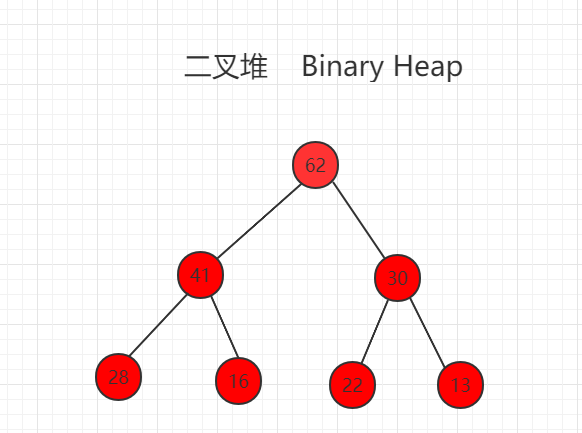
###### 我们可以使用数组存储二叉堆，右边的标号是数组的索引。且堆的索引满足：如果当前节点的索引是i，那么左孩子索引为$2 \times i + 1$，右孩子为$2 \times i + 2$，父节点为$(i - 1) // 2$
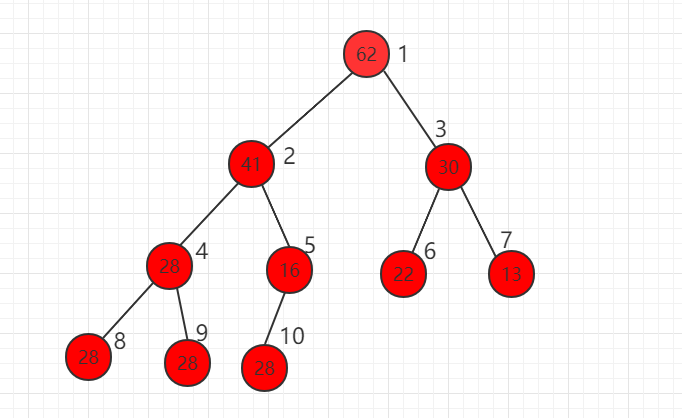

###### 堆的具体实现：主要操作有堆的定义，节点下标计算，寻找最大值，删除最大值，统计堆的元素数量，判断堆是否为空，将普通数组转化为最大堆

In [4]:
# 堆的定义
class MaxHeap:
    def __init__(self):
        self.heap = []
    
    # 节点下标计算
    def _parent(self, index): # 对于index = 0 时，返回值是-1，所以在调用此函数时注意确保index > 0
        return (index - 1) // 2
    def _left_child(self, index):
        return 2 * index + 1
    def _right_child(self, index):
        return 2 * index + 2
    
    # 插入
    def insert(self, data):
        self.heap.append(data)
        index = len(self.heap) - 1
        self._sift_up(index) # 插入后为保证最大二叉堆的性质，需要对插入的值进行判断来实行上浮操作
    
    # 上浮
    def _sift_up(self, index):
        while index > 0:
            parent_index = self._parent(index)
            if self.heap[index] > self.heap[parent_index]:
                self.heap[index], self.heap[parent_index] = self.heap[parent_index], self.heap[index]
                index = parent_index
            else:
                break
        return True
    
    # 寻找最大值
    def peek(self):
        if not self.heap:
            return None
        return self.heap[0]

    # 删除最大值
    def pop(self):
        if not self.heap:
            return None
        max_value = self.heap[0]
        index = len(self.heap) - 1
        # 和insert类似，不过需要先将第一个和最后一个互换位置，然后将根节点下沉
        self.heap[0], self.heap[index] = self.heap[index], self.heap[0]
        self.heap.pop()
        if self.heap:
            self._sift_down(0)
        return max_value
    
    # 下沉
    def _sift_down(self, index):
        while True:
            left_index = self._left_child(index)
            right_index = self._right_child(index)
            # 设置一个最大索引来进行比较
            largest_index = index
            # 比较左孩子
            if left_index < len(self.heap) and self.heap[left_index] > self.heap[largest_index]:
                largest_index = left_index
            if right_index < len(self.heap) and self.heap[right_index] > self.heap[largest_index]:
                largest_index = right_index
            if index == largest_index:
                break
            self.heap[index], self.heap[largest_index] = self.heap[largest_index], self.heap[index]
            # 继续从交换后的新位置向下检查
            index = largest_index
        return True
    
    # 获取堆的数量
    def size(self):
        return len(self.heap)
    
    # 判断堆是否为空
    def is_empty(self):
        return not self.heap
    
    # 将数组转化为最大堆
    def heapify(self, array):
        self.heap = array.copy()
        last_index = len(self.heap) - 1
        index = (last_index - 1) // 2
        for i in range(index, -1, -1):
            self._sift_down(i)
    
# 堆排序
def heap_sort(array):
    n = len(array)
    for i in range((n-2) // 2, -1, -1):
        _sift_down(array, i, n)
    for end in range(n-1, 0, -1):
        array[0], array[end] = array[end], array[0]

        _sift_down(array, 0, end)
    return array
def _sift_down(array, index, heap_size):
    while True:
        left_index = 2 * index + 1
        right_index = 2 * index + 2
        largest_index = index
        if left_index < heap_size and array[left_index] > array[largest_index]:
            largest_index = left_index

        if right_index < heap_size and array[right_index] > array[largest_index]:
            largest_index = right_index

        if largest_index == index:
            break

        array[index], array[largest_index] = array[largest_index], array[index]

        index = largest_index
        

heap = MaxHeap()

for x in [50, 30, 80, 20, 70, 90, 60]:
    heap.insert(x)

print(heap.heap)
print("最大值:", heap.peek())

while heap.heap:
    print(heap.pop(), end=" ")

array = [20, 50, 30, 80, 10, 90, 40]
heap.heapify(array)

print(heap.heap)

array1 = [20, 50, 30, 80, 10, 90, 40]

print(heap_sort(array1))

[90, 70, 80, 20, 30, 50, 60]
最大值: 90
90 80 70 60 50 30 20 [90, 80, 40, 50, 10, 30, 20]
[10, 20, 30, 40, 50, 80, 90]
